In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# MGCAMBのパスを追加 (ユーザー環境に合わせて設定)
sys.path.insert(0, '/home/tanida/cocoa_v41/cocoa/Cocoa/external_modules/code/MGCAMB')
import camb
from camb import model
print("MGCAMB loaded successfully.")

MGCAMB loaded successfully.


In [233]:
def get_mgcamb_pk(mu0_val, z_eff=0.5893):
    """
    指定されたmu0で線形P(k)を計算する関数
    """
    # 宇宙論パラメータの設定
    params = camb.CAMBparams()
    params.set_cosmology(
        H0=67.089,
        ombh2=0.0222499167450714,
        omch2=0.11915441939660276,
        mnu=0.00,
        omk=0,
        tau=0.0697186,
        nnu=3.046,
        # num_massive_neutrinos=1
        num_massive_neutrinos=0
    )
    params.AccuracyBoost = 3.0   # 標準は1.0、これを大幅に上げる
    params.lAccuracyBoost = 3.0
    # params.accurate_massive_neutrino_transfers = True

    # MGCAMB固有の設定
    params.MG_wrapped = True
    params.MG_flag = 1
    params.pure_MG_flag = 2  # mu-Sigma parametrization

    params.GRtrans = 0.2

    params.muSigma_par = 1  # 背景はGR、摂動のみMG
    params.mu0 = mu0_val     # ここでmu0を変更
    params.sigma0 = 1.0      # 今回はsigma0は固定

    params.muSigma_par = 1  # 背景はGR、摂動のみMG
    
    params.InitPower.set_params(As=2.2065e-09, ns=0.9645)
    params.set_dark_energy(w=-1.0, dark_energy_model='ppf')
    # params.set_dark_energy(w=-1.0, dark_energy_model='fluid')

    # P(k)計算の設定
    params.set_matter_power(redshifts=[z_eff], kmax=1e3, k_per_logint=30, nonlinear=False)
    # params.set_matter_power(redshifts=[z_eff], kmax=1e3, k_per_logint=100)
    # params.NonLinear = model.NonLinear_none
    # params.NonLinear = model.NonLinear_pk

    # 計算実行
    results = camb.get_results(params)
    
    # P(k)の取得
    # kの範囲は比較のために固定範囲を指定するのが望ましいですが、
    # ここではCAMBの出力グリッドを使用します。
    kh, z_arr, pk = results.get_matter_power_spectrum(
        minkh=1e-6, 
        maxkh=1e3, 
        npoints=200
    )
    
    return kh, pk[0, :] # z_effでのP(k)を返す

In [234]:
z_target = 0.
# z_target = 0.5893

# 1. mu0 = 0.0 (GR limit) の計算
print("Calculating for mu0 = 0.0 (GR)...")
k_gr, pk_gr = get_mgcamb_pk(mu0_val=0.0, z_eff=z_target)

# 2. mu0 = 0.1 の計算
print("Calculating for mu0 = 0.1 (MG)...")
k_mu01, pk_mu01 = get_mgcamb_pk(mu0_val=0.1, z_eff=z_target)

# 2. mu0 = 0.6 の計算
print("Calculating for mu0 = 0.6 (MG)...")
k_mu06, pk_mu06 = get_mgcamb_pk(mu0_val=0.6, z_eff=z_target)

# 2. mu0 = 0.9 の計算
print("Calculating for mu0 = 0.9 (MG)...")
k_mu09, pk_mu09 = get_mgcamb_pk(mu0_val=0.9, z_eff=z_target)

# 2. mu0 = 1.0 の計算
print("Calculating for mu0 = 1.0 (MG)...")
k_mg, pk_mg = get_mgcamb_pk(mu0_val=1.0, z_eff=z_target)

print("Calculating for mu0 = 1.1 (MG)...")
k_11, pk_mu11 = get_mgcamb_pk(mu0_val=1.1, z_eff=z_target)

print("Calculating for mu0 = 1.3 (MG)...")
k_13, pk_mu13 = get_mgcamb_pk(mu0_val=1.3, z_eff=z_target)


# 3. kグリッドが一致しているか確認 (CAMBの仕様上、同じ設定なら通常一致しますが念のため補間)
if not np.allclose(k_gr, k_mg):
    print("k grids differ slightly, interpolating MG result to GR grid...")
    pk_mg = np.interp(k_gr, k_mg, pk_mg)
    pk_mu01 = np.interp(k_gr, k_mu01, pk_mu01)
    k_plot = k_gr
else:
    k_plot = k_gr

# 4. 相対差 (Ratio) の計算
ratio = pk_mg / pk_gr
# ratio_01 = pk_mu01 / pk_gr
ratio_01 = pk_mu01 / pk_gr
rel_diff = (pk_mg - pk_gr) / pk_gr * 100

Calculating for mu0 = 0.0 (GR)...
Calculating for mu0 = 0.1 (MG)...
Calculating for mu0 = 0.6 (MG)...
Calculating for mu0 = 0.9 (MG)...
Calculating for mu0 = 1.0 (MG)...
Calculating for mu0 = 1.3 (MG)...
Calculating for mu0 = 1.3 (MG)...


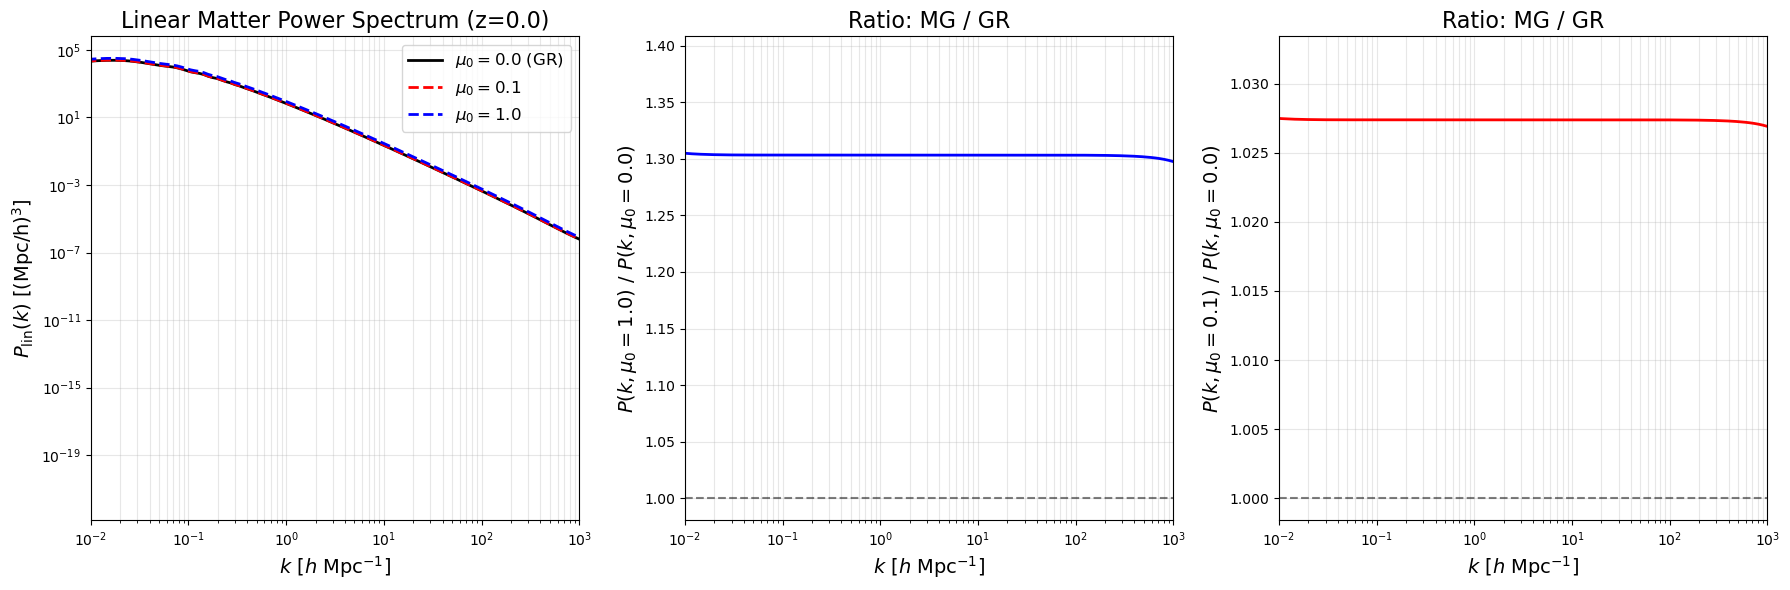

In [256]:
# --- プロット ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 左側: P(k) 絶対値
ax = axes[0]
ax.loglog(k_plot, pk_gr, 'k-', linewidth=2, label=r'$\mu_0=0.0$ (GR)')
ax.loglog(k_plot, pk_mu01, 'r--', linewidth=2, label=r'$\mu_0=0.1$')
ax.loglog(k_plot, pk_mg, 'b--', linewidth=2, label=r'$\mu_0=1.0$')
ax.set_xlabel(r'$k$ [$h$ Mpc$^{-1}$]', fontsize=14)
ax.set_ylabel(r'$P_{\rm lin}(k)$ [(Mpc/h)$^3$]', fontsize=14)
ax.set_title(f'Linear Matter Power Spectrum (z={z_target})', fontsize=16)
ax.legend(fontsize=12)
ax.set_xlim(1e-2, 1e3)
ax.grid(True, alpha=0.3, which="both")

# 右側: 比率 (MG/GR)
ax = axes[1]
ax.semilogx(k_plot, ratio, 'b-', linewidth=2)
ax.axhline(1.0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel(r'$k$ [$h$ Mpc$^{-1}$]', fontsize=14)
ax.set_ylabel(r'$P(k, \mu_0=1.0) \ / \ P(k, \mu_0=0.0)$', fontsize=14)
ax.set_xlim(1e-2, 1e3)
# ax.set_ylim(1.00, 1.15)
ax.set_title(r'Ratio: MG / GR', fontsize=16)
ax.grid(True, alpha=0.3, which="both")

# 右側: 比率 (MG/GR)
ax = axes[2]
# ax.semilogx(k_plot, ratio, 'b-', linewidth=2)
ax.semilogx(k_plot, ratio_01, 'r-', linewidth=2)
ax.axhline(1.0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel(r'$k$ [$h$ Mpc$^{-1}$]', fontsize=14)
ax.set_ylabel(r'$P(k, \mu_0=0.1) \ / \ P(k, \mu_0=0.0)$', fontsize=14)
ax.set_xlim(1e-2, 1e3)
# ax.set_ylim(1.00, 1.15)
ax.set_title(r'Ratio: MG / GR', fontsize=16)
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

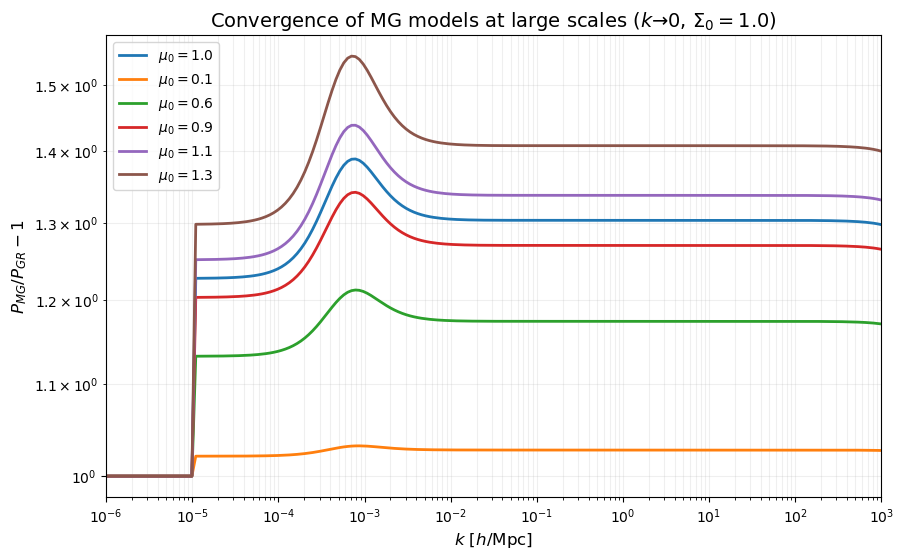

In [238]:
import matplotlib.pyplot as plt
import numpy as np

# 比の計算
ratio_mu10 = (pk_mg / pk_gr) 
ratio_mu01 = (pk_mu01 / pk_gr) 
ratio_mu06 = (pk_mu06 / pk_gr) 
ratio_mu09 = (pk_mu09 / pk_gr) 
ratio_mu11 = (pk_mu11 / pk_gr) 
ratio_mu13 = (pk_mu13 / pk_gr) 

plt.figure(figsize=(10, 6))

# mu0 = 1.0 のプロット
plt.loglog(k_plot, ratio_mu10, label=r'$\mu_0 = 1.0$', lw=2)
# mu0 = 0.1 のプロット
plt.loglog(k_plot, ratio_mu01, label=r'$\mu_0 = 0.1$', lw=2)

plt.loglog(k_plot, ratio_mu06, label=r'$\mu_0 = 0.6$', lw=2)
plt.loglog(k_plot, ratio_mu09, label=r'$\mu_0 = 0.9$', lw=2)
plt.loglog(k_plot, ratio_mu11, label=r'$\mu_0 = 1.1$', lw=2)
plt.loglog(k_plot, ratio_mu13, label=r'$\mu_0 = 1.3$', lw=2)

# ホライゾンスケールの目安 (z=0付近)
# k_h = 2.3e-4 # h/Mpc
# plt.axvline(k_h, color='gray', linestyle='--', alpha=0.5, label='Approx. Horizon Scale')

plt.xlabel(r'$k$ [$h$/Mpc]', fontsize=12)
plt.ylabel(r'$P_{MG}/P_{GR} - 1$', fontsize=12)
plt.title(r'Convergence of MG models at large scales ($k \to 0$, $\Sigma_0=1.0$)', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

# 軸の範囲を調整して、超ホライゾン領域をよく見えるようにする
plt.xlim(k_plot.min(), 1e3)
plt.show()

Transition region slope: -0.5973


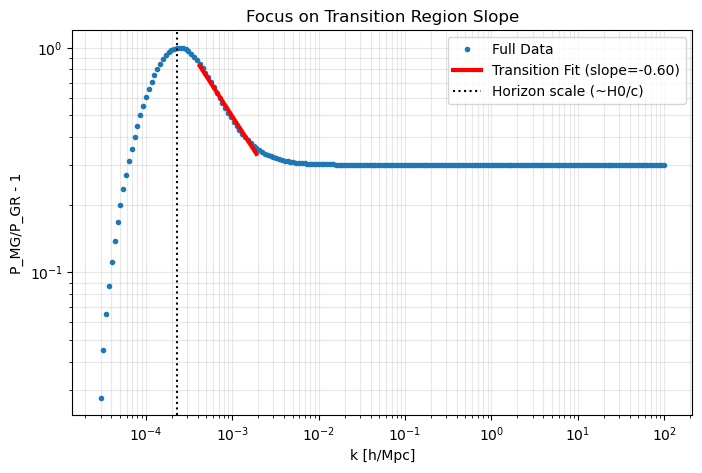

In [182]:
import numpy as np
import matplotlib.pyplot as plt

# 比の増分
diff_ratio = (pk_mg / pk_gr) - 1

# 遷移領域 (上昇している部分) を抽出: 1e-3 < k < 1e-2 あたりが適当
# お手元のプロットに基づき、ピークの右側を指定します
mask_transition = (k_plot > 4e-4) & (k_plot < 2e-3)

if np.any(mask_transition):
    log_k_trans = np.log10(k_plot[mask_transition])
    log_y_trans = np.log10(diff_ratio[mask_transition])

    # 傾きを計算
    slope_trans, intercept_trans = np.polyfit(log_k_trans, log_y_trans, 1)

    print(f"Transition region slope: {slope_trans:.4f}")
    
    # 描画
    plt.figure(figsize=(8, 5))
    plt.loglog(k_plot, diff_ratio, '.', label='Full Data')
    plt.loglog(k_plot[mask_transition], 10**(slope_trans * log_k_trans + intercept_trans), 
               'r-', lw=3, label=f'Transition Fit (slope={slope_trans:.2f})')
    plt.axvline(2.3e-4, color='k', linestyle=':', label='Horizon scale (~H0/c)')
    plt.xlabel('k [h/Mpc]')
    plt.ylabel('P_MG/P_GR - 1')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.title('Focus on Transition Region Slope')
    plt.show()
else:
    print("Mask range is empty. Adjust k limits.")

## 260109 CosmoLike's P(k) vs cocoa's MGCAMB's P(k) at z = CMASS1

Calculating MGCAMB for mu0 = 0.0...
mu0=0.0 | Target s8(z=0): 0.812 | Calculated s8(z=0.6264): 0.5863
Calculating MGCAMB for mu0 = 1.0...
mu0=1.0 | Target s8(z=0): 0.812 | Calculated s8(z=0.6264): 0.5452


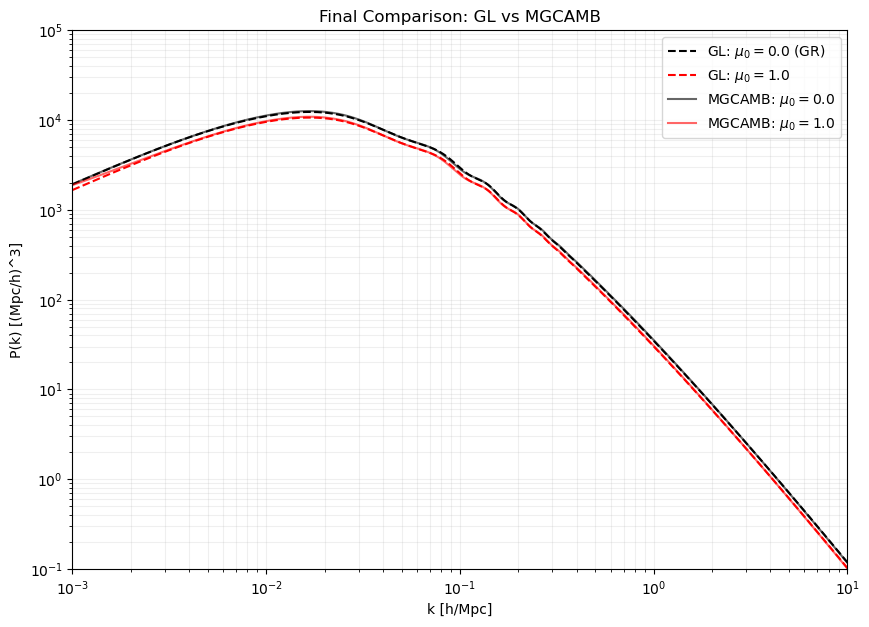

In [362]:
import numpy as np
import matplotlib.pyplot as plt

def get_CMASS1_pk_with_MGCAMB(mu0_val, target_sigma8=0.8120, z_eff=0.6264):
    # GLのPlanck_paramsに準拠
    h = 0.6732
    ob = 0.049389
    oc = 0.26503
    ns = 0.96605
    
    params = camb.CAMBparams()
    params.set_cosmology(H0=h*100, ombh2=ob*h**2, omch2=oc*h**2, mnu=0.0, omk=0, tau=0.0697186, nnu=3.046)
    
    # MGCAMB 設定
    params.MG_wrapped = True
    params.MG_flag = 1
    params.pure_MG_flag = 2
    params.GRtrans = 0.2
    params.muSigma_par = 1
    params.mu0 = mu0_val
    params.sigma0 = 0.0
    params.InitPower.set_params(As=2.1e-09, ns=ns)

    # 1. z=0.0 で sigma8 を確認（規格化のため）
    params.set_matter_power(redshifts=[0.0], kmax=20.0, nonlinear=False)
    results = camb.get_results(params)
    current_s8_z0 = results.get_sigma8()[0]
    
    # 2. As を補正して、目的の z_eff で再計算
    new_As = 2.1e-09 * (target_sigma8 / current_s8_z0)**2
    params.InitPower.set_params(As=new_As, ns=ns)
    params.set_matter_power(redshifts=[z_eff], kmax=20.0, nonlinear=False)
    
    results = camb.get_results(params)
    kh, z_arr, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=20.0, npoints=2000)
    
    print(f"mu0={mu0_val} | Target s8(z=0): {target_sigma8} | Calculated s8(z={z_eff}): {results.get_sigma8()[0]:.4f}")
    return kh, pk[0, :]

# --- 実行とプロット ---

# 宇宙論パラメータのターゲット
t_sigma8 = 0.8120
z_c2 = 0.6264
# z_c2 = 0.0

print("Calculating MGCAMB for mu0 = 0.0...")
kh_mg_00, pk_mg_00 = get_CMASS1_pk_with_MGCAMB(0.0, t_sigma8, z_c2)

print("Calculating MGCAMB for mu0 = 1.0...")
kh_mg_10, pk_mg_10 = get_CMASS1_pk_with_MGCAMB(1.0, t_sigma8, z_c2)

# プロット
plt.figure(figsize=(10, 7))

# GL側のデータ（以前 np.loadtxt した変数を使用）
plt.loglog(k_gl_00, pk_gl_00, 'k--', label='GL: $\mu_0=0.0$ (GR)')
plt.loglog(k_gl_10, pk_gl_10, 'r--', label='GL: $\mu_0=1.0$')

# MGCAMBの結果
plt.loglog(kh_mg_00, pk_mg_00, 'k-', alpha=0.6, label='MGCAMB: $\mu_0=0.0$')
plt.loglog(kh_mg_10, pk_mg_10, 'r-', alpha=0.6, label='MGCAMB: $\mu_0=1.0$')

plt.xlim(1e-3, 10)
plt.ylim(1e-1, 1e5)
plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) [(Mpc/h)^3]')
plt.title('Final Comparison: GL vs MGCAMB')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()




# # # def get_CMASS1_pk_with_MGCAMB(mu0_val, target_sigma8=0.8120, z_eff=0.6264):
# # #     """
# # #     指定されたmu0とtarget_sigma8で線形P(k)を計算する関数
# # #     """
# # #     # 宇宙論パラメータの設定
# # #     params = camb.CAMBparams()
# # #     params.set_cosmology(
# # #         H0=67.089, # power_lin_CMASSのcparams["h"]=0.67089と合わせるなら67.089
# # #         ombh2=0.0222499167450714,
# # #         omch2=0.11915441939660276,
# # #         mnu=0.00,
# # #         omk=0,
# # #         tau=0.0697186,
# # #         nnu=3.046,
# # #         num_massive_neutrinos=0
# # #     )
# # #     params.AccuracyBoost = 3.0
# # #     params.lAccuracyBoost = 3.0

# # #     # MGCAMB固有の設定
# # #     params.MG_wrapped = True
# # #     params.MG_flag = 1
# # #     params.pure_MG_flag = 2  # mu-Sigma parametrization
# # #     params.GRtrans = 0.2
# # #     params.muSigma_par = 1   # 背景はGR、摂動のみMG
# # #     params.mu0 = mu0_val     # ここでmu0を変更
# # #     params.sigma0 = 0.0      # power_lin_CMASSのSigma_0=0.0と合わせる

# # #     # 初期揺らぎの設定 (まずは適当なAsで計算)
# # #     initial_As = 2.1e-09
# # #     params.InitPower.set_params(As=initial_As, ns=0.9645)
# # #     params.set_dark_energy(w=-1.0, dark_energy_model='ppf')

# # #     # P(k)計算の設定
# # #     params.set_matter_power(redshifts=[z_eff], kmax=1e2, k_per_logint=30, nonlinear=False)

# # #     # --- 1回目の計算: 現在のsigma8を確認 ---
# # #     results = camb.get_results(params)
# # #     current_sigma8 = results.get_sigma8()
    
# # #     # --- Asのスケーリング ---
# # #     # As ∝ (sigma8)^2 の関係を利用して、目標のsigma8になるAsを逆算
# # #     new_As = initial_As * (target_sigma8 / current_sigma8)**2
# # #     params.InitPower.set_params(As=new_As, ns=0.9645)
    
# # #     # --- 2回目の計算: 本番 ---
# # #     results = camb.get_results(params)
    
# # #     # P(k)の取得
# # #     kh, z_arr, pk = results.get_matter_power_spectrum(
# # #         minkh=1e-6, 
# # #         maxkh=1e3, 
# # #         npoints=2000 # power_lin_CMASSのkの数(2000)と合わせる
# # #     )
    
# # #     # 計算された sigma8 を確認のためにプリント（不要なら消してください）
# # #     # print(f"Target sigma8: {target_sigma8}, Calculated sigma8: {results.get_sigma8():.6f}")
# # #     print(f"Target sigma8: {target_sigma8}, Calculated sigma8: {results.get_sigma8()[0]:.6f}")
    
# # #     return kh, pk[0, :] # z_effでのP(k)を返す

# # def get_CMASS1_pk_with_MGCAMB(mu0_val, target_sigma8=0.8120, z_eff=0.6264):
# #     """
# #     指定されたmu0とz=0でのtarget_sigma8を使って線形P(k)を計算する
# #     """
# #     # GL側の Planck_params() に完全に合わせる
# #     h = 0.6732
# #     ob = 0.049389
# #     oc = 0.26503
# #     ns = 0.96605
    
# #     params = camb.CAMBparams()
# #     params.set_cosmology(
# #         H0 = h * 100.0,
# #         ombh2 = ob * h**2,
# #         omch2 = oc * h**2,
# #         mnu = 0.0, # ニュートリノを一旦0にする
# #         omk = 0,
# #         tau = 0.0697186,
# #         nnu = 3.046,
# #         num_massive_neutrinos = 0
# #     )
# #     params.InitPower.set_params(As=2.1e-09, ns=ns)
    
# #     # MGCAMB設定
# #     params.MG_wrapped = True
# #     params.MG_flag = 1
# #     params.pure_MG_flag = 2
# #     # params.GRtrans = 0.2
# #     params.muSigma_par = 1
# #     params.mu0 = mu0_val
# #     params.sigma0 = 0.0

# #     # redshiftsを [z_eff, 0.0] と明示的に大きい順に並べる
# #     params.set_matter_power(redshifts=[z_eff, 0.0], kmax=10.0, k_per_logint=30, nonlinear=False)

# #     # 1回目の計算
# #     results = camb.get_results(params)
# #     s8_results = results.get_sigma8()
# #     # CAMBの仕様を確認するため print を追加
# #     # s8_results[0] が z_eff, s8_results[1] が z=0.0 になるはず
# #     current_sigma8_z0 = s8_results[1] 
    
# #     # Asのスケーリング (z=0のsigma8を基準に)
# #     new_As = 2.1e-09 * (target_sigma8 / current_sigma8_z0)**2
# #     params.InitPower.set_params(As=new_As, ns=ns)
    
# #     # 2回目の計算
# #     results = camb.get_results(params)
    
# #     kh, z_arr, pk = results.get_matter_power_spectrum(
# #         minkh=1e-3, 
# #         maxkh=10.0, 
# #         npoints=2000
# #     )
    
# #     # どのインデックスがどのzかを確認
# #     print(f"Index 0 redshift: {z_arr[0]}, sigma8: {results.get_sigma8()[0]:.4f}")
# #     print(f"Index 1 redshift: {z_arr[1]}, sigma8: {results.get_sigma8()[1]:.4f}")
    
# #     # z_eff に対応するインデックス（通常は 0）を返す
# #     return kh, pk[0, :]

# def get_CMASS1_pk_with_MGCAMB(mu0_val, target_sigma8=0.8120, z_eff=0.6264):
#     """
#     z=0.0でのsigma8をtarget_sigma8に合わせた上で、z_effでのパワースペクトルを返す
#     """
#     h = 0.6732
#     ob = 0.049389
#     oc = 0.26503
#     ns = 0.96605
    
#     params = camb.CAMBparams()
#     params.set_cosmology(H0=h*100, ombh2=ob*h**2, omch2=oc*h**2, mnu=0.0, omk=0, tau=0.0697186, nnu=3.046, num_massive_neutrinos=0)
#     params.InitPower.set_params(As=2.1e-09, ns=ns)
    
#     params.MG_wrapped = True
#     params.MG_flag = 1
#     params.pure_MG_flag = 2
#     params.GRtrans = 0.2
#     params.muSigma_par = 1
#     params.mu0 = mu0_val
#     params.sigma0 = 0.0

#     # 赤方偏移を指定
#     z_list = [0.0, z_eff]
#     params.set_matter_power(redshifts=z_list, kmax=10.0, k_per_logint=30, nonlinear=False)

#     # 1回目の計算：z=0.0の場所を探してスケーリング
#     results = camb.get_results(params)
#     z_out = results.transfer_redshifts # CAMBが実際に出力に使ったzの順序
#     s8_list = results.get_sigma8()
#     # print(results.get_sigma8_0())
#     print("z_out: ", z_out[0])
    
#     # z=0.0 に対応する sigma8 を取得
#     idx_z0 = np.argmin(np.abs(np.array(z_out) - 0.0))
#     current_sigma8_z0 = s8_list[idx_z0]
    
#     # Asをスケーリング
#     new_As = 2.1e-09 * (target_sigma8 / current_sigma8_z0)**2
#     params.InitPower.set_params(As=new_As, ns=ns)
    
#     # 2回目の計算
#     results = camb.get_results(params)
#     kh, z_out, pk = results.get_matter_power_spectrum(minkh=1e-3, maxkh=10.0, npoints=2000)
    
#     # z=z_eff に対応するインデックスのpkを返す
#     idx_zeff = np.argmin(np.abs(np.array(z_out) - z_eff))
    
#     print(f"--- Results for mu0 = {mu0_val} ---")
#     for i, z in enumerate(z_out):
#         print(f"  z = {z:.4f}: sigma8 = {results.get_sigma8()[i]:.4f}")
    
#     return kh, pk[idx_zeff, :]

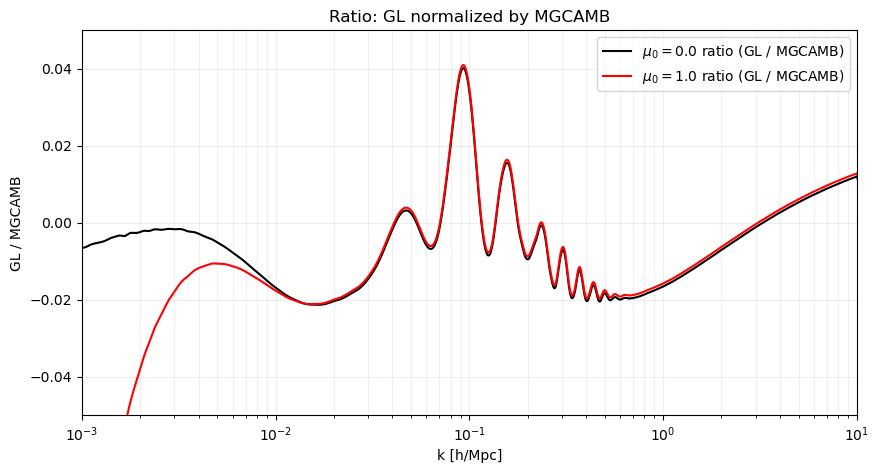

In [375]:
plt.figure(figsize=(10, 5))

# MGCAMB をベースにするための関数
def get_ratio_mg_base(kh_mg, pk_mg, k_gl, pk_gl):
    # GL のデータを MGCAMB の k グリッドに合わせて補間
    f_gl = interp1d(k_gl, pk_gl, bounds_error=False, fill_value="extrapolate")
    # GL / MGCAMB の比を計算
    return (f_gl(kh_mg)-pk_mg) / pk_mg

# 比を計算
ratio_00 = get_ratio_mg_base(kh_mg_00, pk_mg_00, k_gl_00, pk_gl_00)
ratio_10 = get_ratio_mg_base(kh_mg_10, pk_mg_10, k_gl_10, pk_gl_10)

# プロット
# MGCAMB の k (kh_mg_00) を横軸にしてプロットします
plt.semilogx(kh_mg_00, ratio_00, 'k-', label='$\mu_0=0.0$ ratio (GL / MGCAMB)')
plt.semilogx(kh_mg_10, ratio_10, 'r-', label='$\mu_0=1.0$ ratio (GL / MGCAMB)')

# plt.axhline(1.0, color='gray', linestyle='--')
plt.xlabel('k [h/Mpc]')
plt.ylabel('GL / MGCAMB')

# 表示範囲を MGCAMB が計算されている範囲に合わせる
plt.xlim(1e-3, 10)
plt.ylim(-0.05, 0.05) 

plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.title('Ratio: GL normalized by MGCAMB')
plt.show()

# plt.figure(figsize=(10, 5))

# def get_ratio(k_gl, pk_gl, kh_mg, pk_mg):
#     f_mg = interp1d(kh_mg, pk_mg, bounds_error=False, fill_value="extrapolate")
#     return f_mg(k_gl) / pk_gl

# plt.semilogx(k_gl_00, get_ratio(k_gl_00, pk_gl_00, kh_mg_00, pk_mg_00), 'k-', label='$\mu_0=0.0$ ratio')
# plt.semilogx(k_gl_10, get_ratio(k_gl_10, pk_gl_10, kh_mg_10, pk_mg_10), 'r-', label='$\mu_0=1.0$ ratio')

# # plt.axhline(1.0, color='gray', linestyle='--')
# plt.xlabel('k [h/Mpc]')
# plt.ylabel('MGCAMB / GL')
# # plt.ylim(0.95, 1.05) 
# plt.legend()
# plt.grid(True, which="both", ls="-", alpha=0.2)
# plt.title('Ratio: MGCAMB / GL')
# plt.show()

# # import numpy as np
# # import matplotlib.pyplot as plt

# # 1. GL側で計算されたデータを読み込む (0.0 と 1.0 のみ)
# gl_path = "/home/tanida/GL/valid_test/power/"
# k_gl_00, pk_gl_00 = np.loadtxt(f"{gl_path}CMASS2_0000.dat", unpack=True)
# k_gl_10, pk_gl_10 = np.loadtxt(f"{gl_path}CMASS2_1000.dat", unpack=True)

# # 2. MGCAMBで計算 (mu0 = 0.0, 1.0 のみ)
# t_sigma8 = 0.8120
# z_c2 = 0.6264

# print("Calculating MGCAMB: mu0 = 0.0...")
# kh_mg_00, pk_mg_00 = get_CMASS1_pk_with_MGCAMB(mu0_val=0.0, target_sigma8=t_sigma8, z_eff=z_c2)

# print("Calculating MGCAMB: mu0 = 1.0...")
# kh_mg_10, pk_mg_10 = get_CMASS1_pk_with_MGCAMB(mu0_val=1.0, target_sigma8=t_sigma8, z_eff=z_c2)

/tmp/ipykernel_2070850/2088567213.py:17: RuntimeWarning: invalid value encountered in log
  return np.log(pk_gl_interp / pk_mg)


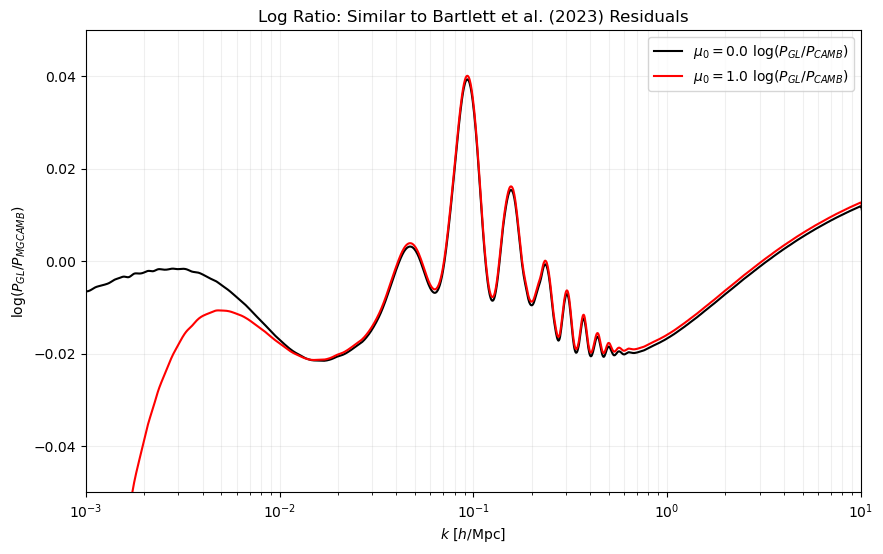

In [376]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

#... (既存のデータ読み込みコード)...

# 関数を修正：Bartlett et al. に倣って「対数比 (log ratio)」を返すように変更
def get_log_ratio(kh_mg, pk_mg, k_gl, pk_gl):
    # GL のデータを MGCAMB の k グリッドに合わせて補間
    f_gl = interp1d(k_gl, pk_gl, bounds_error=False, fill_value="extrapolate")
    pk_gl_interp = f_gl(kh_mg)
    
    # log(P_GL / P_MGCAMB) を計算
    # 注: Bartlettの定義は log(P_True / P_Approx) なので符号が逆になる可能性がありますが、
    # ズレの大きさを見る分には log(A/B) でも log(B/A) でもOKです。
    # ここでは GL (Approx) / MGCAMB (True) とします。
    return np.log(pk_gl_interp / pk_mg)

# 計算
log_ratio_00 = get_log_ratio(kh_mg_00, pk_mg_00, k_gl_00, pk_gl_00)
log_ratio_10 = get_log_ratio(kh_mg_10, pk_mg_10, k_gl_10, pk_gl_10)

# プロット
plt.figure(figsize=(10, 6))

plt.semilogx(kh_mg_00, log_ratio_00, 'k-', label=r'$\mu_0=0.0$ $\log(P_{GL}/P_{CAMB})$')
plt.semilogx(kh_mg_10, log_ratio_10, 'r-', label=r'$\mu_0=1.0$ $\log(P_{GL}/P_{CAMB})$')

plt.xlabel(r'$k$ [$h$/Mpc]')
plt.ylabel(r'$\log(P_{GL} / P_{MGCAMB})$')

# Bartlett Fig 2 (Middle Panel) のスケール感に合わせる
plt.xlim(1e-3, 10)
plt.ylim(-0.05, 0.05) 

plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.title('Log Ratio: Similar to Bartlett et al. (2023) Residuals')
plt.show()

## Planck Prametrization https://arxiv.org/pdf/1703.01271

\mu(k, a) = 1 + E_{11} * \Omega_{DE}(a)

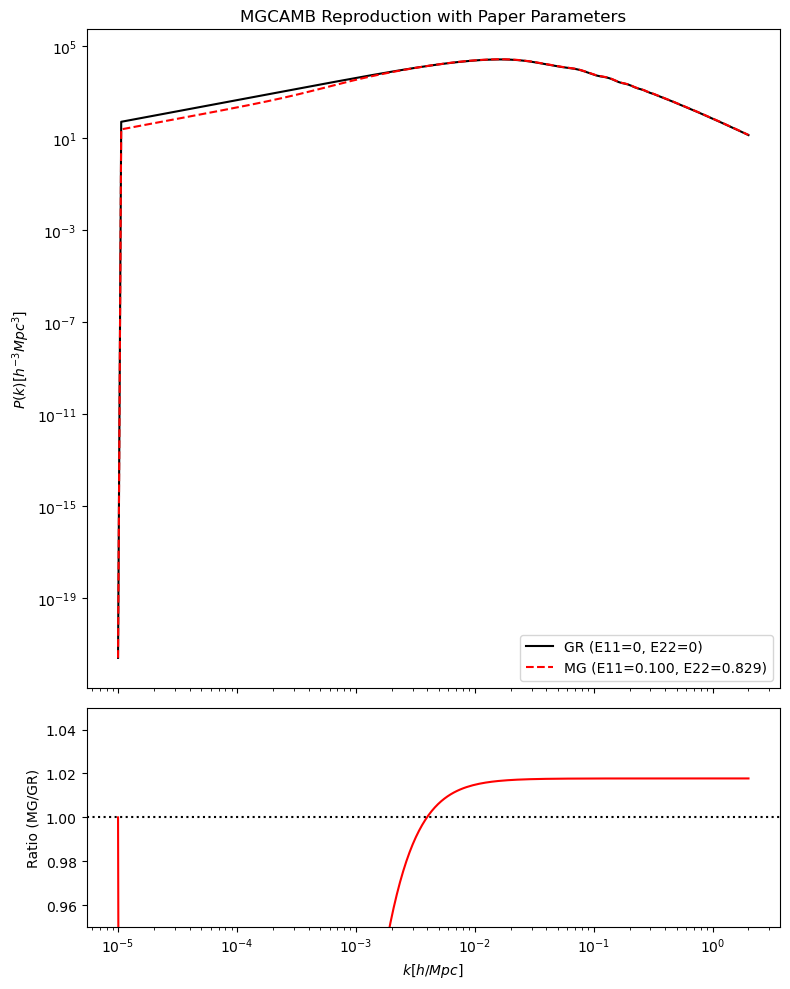

In [203]:
import numpy as np
import matplotlib.pyplot as plt
import camb

def get_mgcamb_pk_exact(E11_val, E22_val, z_eff=0.0):
    h = 0.682
    params = camb.CAMBparams()
    
    # 1. 提供された物理パラメータをセット
    # Omega_m*h^2 に変換して入力
    params.set_cosmology(
        H0 = h * 100,
        ombh2 = 0.048 * (h**2), # Ωb 0.048
        omch2 = 0.254 * (h**2), # Ωc 0.254
        mnu = 0.0,
        omk = 0,
        tau = 0.06 # デフォルト付近
    )
    
    # 2. 初期揺らぎの設定 (10^10 As = 3.063 -> As = e^3.063 * 10^-10)
    # ※もし 3.063 が ln(10^10 As) なら np.exp(3.063)*1e-10
    # ここでは一般的な Planck の As ~ 2e-9 になるよう As = np.exp(3.063)*1e-10 とします
    As_val = np.exp(3.063) * 1e-10 
    params.InitPower.set_params(As=As_val, ns=0.969)
    
    # 3. MGCAMB 固有設定 (Planck Parametrization)
    params.MG_wrapped = True
    params.MG_flag = 1
    params.pure_MG_flag = 1 # mu, gamma
    params.mugamma_par = 2  # Planck model (E11, E22)
    
    params.GRtrans = 0.0001    # 以前の議論通り z~4 で MG オン
    
    # 指定の MG パラメータ
    params.E11 = E11_val
    params.E22 = E22_val
    
    params.set_dark_energy(w=-1.0, dark_energy_model='ppf')
    params.set_matter_power(redshifts=[z_eff], kmax=10.0, nonlinear=False)

    # 計算実行
    results = camb.get_results(params)
    kh, _, pk = results.get_matter_power_spectrum(minkh=1e-5, maxkh=2.0, npoints=200)
    
    return kh, pk[0, :]

# --- 指定数値での実行 ---
# 指定値: E11=0.100, E22=0.829
k_exact, pk_mg = get_mgcamb_pk_exact(E11_val=0.100, E22_val=0.829)

# 比較用 GR (E11=0, E22=0)
_, pk_gr = get_mgcamb_pk_exact(E11_val=0.0, E22_val=0.0)

# --- プロット ---
fig, ax = plt.subplots(2, 1, figsize=(8, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax[0].loglog(k_exact, pk_gr, 'k', label='GR (E11=0, E22=0)')
ax[0].loglog(k_exact, pk_mg, 'r--', label='MG (E11=0.100, E22=0.829)')
ax[0].set_ylabel(r'$P(k) [h^{-3} Mpc^3]$')
ax[0].set_title('MGCAMB Reproduction with Paper Parameters')
ax[0].legend()

ax[1].semilogx(k_exact, pk_mg / pk_gr, color='red')
ax[1].axhline(1.0, color='black', ls=':')
ax[1].set_ylabel('Ratio (MG/GR)')
ax[1].set_xlabel('$k [h/Mpc]$')
ax[1].set_ylim(0.95, 1.05) # E11=0.1 なら約 5-8% 程度の増幅が予想されます

plt.tight_layout()
plt.show()

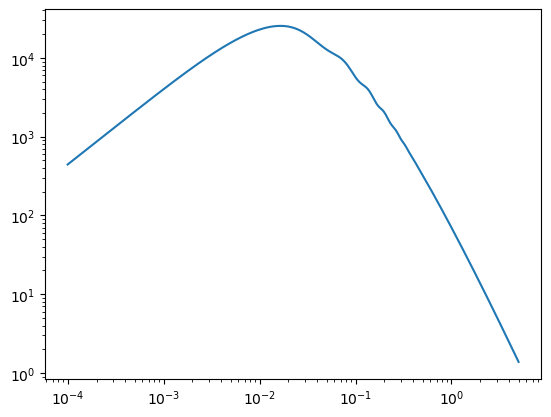

In [ ]:
###

In [345]:
# def get_CMASS1_pk_with_MGCAMB(mu0_val, As_input, z_eff=0.6264):
#     """
#     指定した As_input で線形パワースペクトルを計算し、その時の sigma8 を表示する関数
#     """

#     # 宇宙論パラメータ (GLのPlanck_paramsに準拠)
#     h = 0.6732
#     ob = 0.049389
#     oc = 0.26503
#     ns = 0.96605
    
#     params = camb.CAMBparams()
#     params.set_cosmology(
#         H0=h*100,
#         ombh2=ob*h**2,
#         omch2=oc*h**2,
#         mnu=0.0,
#         omk=0,
#         tau=0.0697186,
#         nnu=3.046,
#         num_massive_neutrinos=0
#     )
    
#     # ユーザーが指定した As を直接設定
#     params.InitPower.set_params(As=As_input, ns=ns)
    
#     # MGCAMBの設定 (mu-Sigma parametrization)
#     params.MG_wrapped = True
#     params.MG_flag = 1
#     params.pure_MG_flag = 2
#     params.muSigma_par = 1
#     params.mu0 = mu0_val
#     params.sigma0 = 0.0
    
#     params.set_dark_energy(w=-1.0, dark_energy_model='ppf')

#     # 計算精度とパワースペクトルの設定
#     params.set_matter_power(redshifts=[0.0, z_eff], kmax=10.0, k_per_logint=30, nonlinear=False)
#     params.AccuracyBoost = 3.0
#     params.lAccuracyBoost = 3.0

#     # 計算実行
#     results = camb.get_results(params)
    
#     # 指定した z_eff での sigma8 を取得して表示
#     current_s8 = results.get_sigma8()[0]
#     print(results.get_sigma8_0())
    
#     print(f"--- MGCAMB Run Status ---")
#     print(f"  Input As        : {As_input:.6e}")
#     print(f"  mu0             : {mu0_val}")
#     print(f"  Sigma8(z={z_eff}): {current_s8:.6f}")
#     print(f"-------------------------")
    
#     # パワースペクトルの取得
#     kh, z_arr, pk = results.get_matter_power_spectrum(
#         minkh=1e-3, 
#         maxkh=10.0, 
#         npoints=2000
#     )
    
#     return kh, pk[0, :]

In [346]:
# # 1. mu0 = 0.0 (GR) の調整
# # Sigma8 が 0.812000 になるように As を微調整する
# as_gr = 2.042e-09 # ここを書き換える
# kh_gr, pk_gr = get_CMASS1_pk_with_MGCAMB(mu0_val=0.0, As_input=as_gr)

# # 2. mu0 = 1.0 の調整
# # 同様に 0.812000 になる As を探す
# as_mg = 1.599e-09 # ここを書き換える
# kh_mg, pk_mg = get_CMASS1_pk_with_MGCAMB(mu0_val=1.0, As_input=as_mg)

Note: redshifts have been re-sorted (earliest first)
0.8120339492880914
--- MGCAMB Run Status ---
  Input As        : 2.042000e-09
  mu0             : 0.0
  Sigma8(z=0.6264): 0.586358
-------------------------
Note: redshifts have been re-sorted (earliest first)
0.8121631408990225
--- MGCAMB Run Status ---
  Input As        : 1.599000e-09
  mu0             : 1.0
  Sigma8(z=0.6264): 0.545553
-------------------------


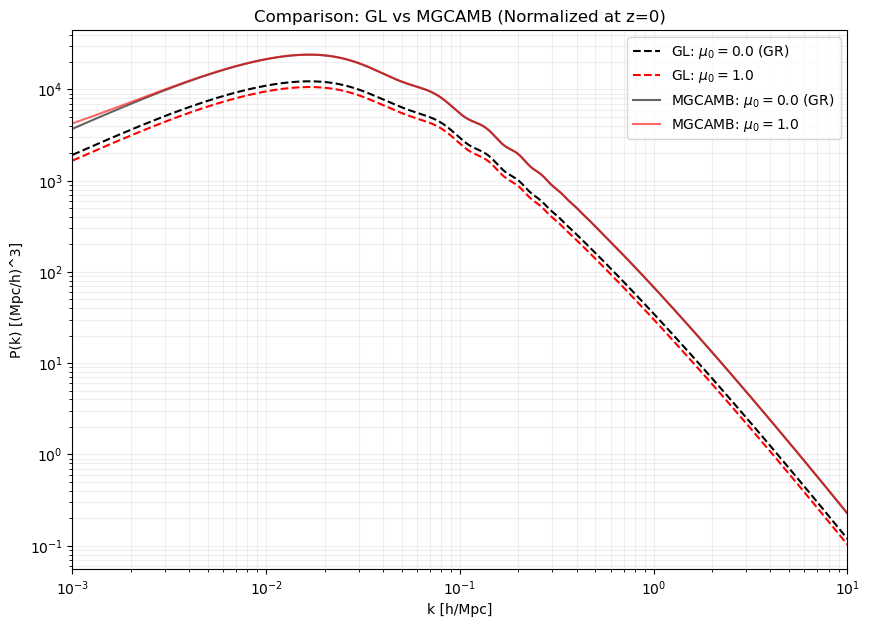

In [352]:
# plt.figure(figsize=(10, 7))

# # 1. GL側のデータを読み込み（以前読み込んだ変数があればそれを使ってください）
# plt.loglog(k_gl_00, pk_gl_00, 'k--', label='GL: $\mu_0=0.0$ (GR)')
# plt.loglog(k_gl_10, pk_gl_10, 'r--', label='GL: $\mu_0=1.0$')

# # 2. 今回計算した MGCAMB の結果をプロット
# plt.loglog(kh_gr, pk_gr, 'k-', alpha=0.6, label='MGCAMB: $\mu_0=0.0$ (GR)')
# plt.loglog(kh_mg, pk_mg, 'r-', alpha=0.6, label='MGCAMB: $\mu_0=1.0$')

# plt.xlim(1e-3, 10)
# plt.xlabel('k [h/Mpc]')
# plt.ylabel('P(k) [(Mpc/h)^3]')
# plt.title('Comparison: GL vs MGCAMB (Normalized at z=0)')
# plt.legend()
# plt.grid(True, which="both", ls="-", alpha=0.2)
# plt.show()

In [ ]:
from scipy.interpolate import interp1d

# plt.plot(k_gl_00, pk_gl_10/pk_gl_00, 'k--', label='GL: MG/GR')
# plt.plot(kh_gr, pk_mg/pk_gr, 'k-', alpha=0.6, label='MGCAMB: GR/MG')
# plt.xscale("log")
# plt.legend()


plt.plot(k_gl_00, pk_gl_10/pk_mg, 'k--', label='GLs MG / MGCAMBs MG')
plt.plot(kh_gr, pk_gl_00/pk_gr, 'k-', alpha=0.6, label='GLs GR MGCAMBs GR')
plt.xscale("log")
plt.legend()